# Getting Started with CMAC

CMAC (Corrected Moments in Antenna Coordinates) is a set of algorithms, built on top of [Py-ART](https://arm-doe.github.io/pyart/), that corrects and adds quality-controlled fields to a radar volume. Starting from a raw radar file and an atmospheric sounding, `cmac()` will:

- classify each radar gate as rain, snow, melting, second trip, no scatter or clutter using fuzzy logic (the `gate_id` field),
- dealias radial velocity (`corrected_velocity`),
- unfold and filter differential phase and compute specific differential phase (`corrected_differential_phase`, `corrected_specific_diff_phase`, ...),
- correct reflectivity and differential reflectivity for attenuation (`corrected_reflectivity`, `corrected_differential_reflectivity`), and
- derive rain and snow rates (`rain_rate_A`, `rain_rate_Z`, `rain_rate_Kdp`, `snow_rate_*`).

More background on CMAC is available at https://arm.gov/data/science-data-products/vaps/cmac.

This notebook walks through processing a single radar volume end to end: downloading a radar file and a matching sounding, running `cmac()`, inspecting the fields it produces, and generating quicklook plots.

## What you'll need

The example below pulls a C-SAPR2 volume and a sounding from ARM Data Discovery using the [Atmospheric data Community Toolkit (ACT)](https://arm-doe.github.io/ACT/), which is installed alongside CMAC. That requires a free ARM Data Discovery account (https://adc.arm.gov) — set your credentials as environment variables before starting Jupyter:

```bash
export ARM_USERNAME=your_username
export ARM_PASSWORD=your_api_token
```

If you'd rather use your own local radar and sonde files, skip the download step below and set `radar_file` / `sonde_file` directly.

In [10]:
import os
import glob

import act
import matplotlib.pyplot as plt
import pyart
import xarray as xr

from cmac import cmac, area_coverage, quicklooks_rhi

%matplotlib inline

## 1. Get a radar file and a sounding

CMAC needs two inputs: a radar volume (read by Py-ART) and a nearby atmospheric sounding (read as an `xarray.Dataset`) used to build the freezing level and a simulated wind profile for velocity dealiasing.

Here we grab ten minutes of C-SAPR2 data from the ARM BNF site, along with the closest radiosonde launch, using `act.discovery.download_arm_data`. Any ARM datastream will work as long as there is a matching entry for it in `cmac.default_config` (or in a YAML file you supply — see the end of this notebook).

In [4]:
username = os.getenv('ARM_USERNAME')
token = os.getenv('ARM_PASSWORD')

data_dir = './cmac_example_data'
os.makedirs(data_dir, exist_ok=True)

radar_config = 'bnf_csapr2_ppi'

act.discovery.download_arm_data(
    username, token, 'bnfcsapr2cfrS3.a1',
    '2025-05-20T00:00:00', '2025-05-20T00:10:00',
    output=data_dir)
act.discovery.download_arm_data(
    username, token, 'bnfsondewnpnM1.b1',
    '2025-05-19T21:00:00', '2025-05-20T03:00:00',
    output=data_dir)

# The bnfcsapr2cfrS3.a1 datastream contains both RHI and PPI scans in the
# same time window; grab the PPI volume for this walkthrough.
radar_files = sorted(glob.glob(f'{data_dir}/**/bnfcsapr2cfrS3*', recursive=True))
sonde_files = sorted(glob.glob(f'{data_dir}/**/bnfsondewnpnM1*', recursive=True))

radar_file = radar_files[-1]
sonde_file = sonde_files[0]
print('Radar file:', radar_file)
print('Sonde file:', sonde_file)

[DOWNLOADING] bnfcsapr2cfrS3.a1.20250520.000000.nc
[DOWNLOADING] bnfcsapr2cfrS3.a1.20250520.000009.nc
[DOWNLOADING] bnfcsapr2cfrS3.a1.20250520.001000.nc

If you use these data to prepare a publication, please cite:

Bharadwaj, N., Collis, S., Hardin, J., Isom, B., Lindenmaier, I., Matthews, A.,
Nelson, D., Feng, Y.-C., Rocque, M., Wendler, T., & Castro, V. C-Band Scanning
ARM Precipitation Radar (CSAPR2CFR), 2025-05-20 to 2025-05-20, Bankhead National
Forest, AL, USA; Long-term Mobile Facility (BNF), Bankhead National Forest, AL,
AMF3 (for CSAPR2 near Main Site) (S3). Atmospheric Radiation Measurement (ARM)
User Facility. https://doi.org/10.5439/1467901

[DOWNLOADING] bnfsondewnpnM1.b1.20250519.232900.cdf

If you use these data to prepare a publication, please cite:

Keeler, E., Burk, K., & Kyrouac, J. Balloon-Borne Sounding System (SONDEWNPN),
2025-05-19 to 2025-05-20, Bankhead National Forest, AL, USA; Long-term Mobile
Facility (BNF), Bankhead National Forest, AL, AMF3 (Main Site) (M

## 2. Read the radar and sonde

The radar file is read with `pyart.io.read`, giving a Py-ART `Radar` object. The sonde is opened directly with `xarray` — `cmac()` reads the temperature, altitude and wind variables out of it by name (as configured for `bnf_csapr2_ppi` in `cmac.config`).

In [5]:
radar = pyart.io.read(radar_file)
sonde = xr.open_dataset(sonde_file)

print(radar.info('compact'))

altitude: <ndarray of type: float32 and shape: (1,)>
altitude_agl: None
antenna_transition: None
azimuth: <ndarray of type: float32 and shape: (177,)>
elevation: <ndarray of type: float32 and shape: (177,)>
fields:
	attenuation_corrected_differential_reflectivity: <ndarray of type: float32 and shape: (177, 1100)>
	attenuation_corrected_differential_reflectivity_lag_1: <ndarray of type: float32 and shape: (177, 1100)>
	attenuation_corrected_reflectivity_h: <ndarray of type: float32 and shape: (177, 1100)>
	censor_mask: <ndarray of type: int32 and shape: (177, 1100)>
	classification_mask: <ndarray of type: int32 and shape: (177, 1100)>
	copol_correlation_coeff: <ndarray of type: float32 and shape: (177, 1100)>
	differential_phase: <ndarray of type: float32 and shape: (177, 1100)>
	differential_reflectivity: <ndarray of type: float32 and shape: (177, 1100)>
	differential_reflectivity_lag_1: <ndarray of type: float32 and shape: (177, 1100)>
	mean_doppler_velocity: <ndarray of type: float32

A quick look at the raw reflectivity before any corrections are applied:

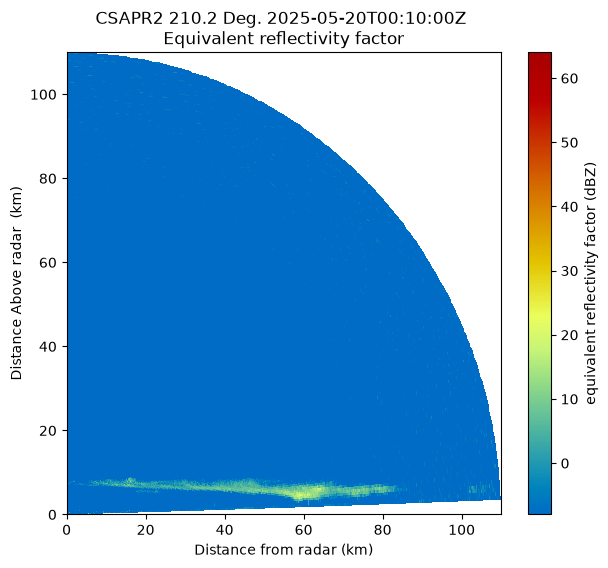

In [8]:
display = pyart.graph.RadarDisplay(radar)
fig = plt.figure(figsize=(7, 6))
display.plot_rhi('reflectivity', sweep=0, vmin=-8, vmax=64, cmap='HomeyerRainbow')

## 3. Run CMAC

`cmac()` takes the radar object, the sonde dataset, and the name of a radar configuration (`radar_config` above) that tells it which field names, thresholds and metadata to use. It returns the same radar object with all of the corrected/derived fields added in place.

In [9]:
cmac_radar = cmac(radar, sonde, radar_config, verbose=True)
sonde.close()

##
## These radar fields are being added:
##    sounding_temperature
##    height
##    signal_to_noise_ratio
##    velocity_texture
##
## CMAC calculation using fuzzy logic:
##    Doing multi_trip
##    Doing rain
##    Doing snow
##    Doing no_scatter
##    Doing melting
##    Doing hard constraining melting
##     (array([  0,   0,   0, ..., 176, 176, 176], shape=(13815,)), array([  3,   4,   5, ..., 892, 893, 894], shape=(13815,)))
##    Doing hard constraining multi_trip
##     (array([  0,   0,   0, ..., 169, 169, 169], shape=(151428,)), array([ 100,  101,  102, ..., 1097, 1098, 1099], shape=(151428,)))
##    Doing hard constraining melting
##     (array([  0,   0,   0, ..., 176, 176, 176], shape=(173049,)), array([ 0,  1,  2, ..., 94, 95, 96], shape=(173049,)))
##    Doing hard constraining rain
##     (array([  0,   0,   0, ..., 174, 174, 174], shape=(41420,)), array([  53,   54,   55, ..., 1097, 1098, 1099], shape=(41420,)))
##    Doing hard constraining snow
##     (array([ 

The fields `cmac()` added, beyond what the original radar file contained:

In [11]:
sorted(cmac_radar.fields.keys())

['attenuation_corrected_differential_reflectivity',
 'attenuation_corrected_differential_reflectivity_lag_1',
 'attenuation_corrected_reflectivity_h',
 'censor_mask',
 'classification_mask',
 'copol_correlation_coeff',
 'corrected_differential_phase',
 'corrected_differential_reflectivity',
 'corrected_reflectivity',
 'corrected_specific_diff_phase',
 'corrected_velocity',
 'differential_phase',
 'differential_reflectivity',
 'differential_reflectivity_lag_1',
 'filtered_corrected_differential_phase',
 'filtered_corrected_specific_diff_phase',
 'gate_id',
 'height',
 'height_over_iso0',
 'mean_doppler_velocity',
 'mean_doppler_velocity_v',
 'normalized_coherent_power',
 'normalized_coherent_power_v',
 'path_integrated_attenuation',
 'path_integrated_differential_attenuation',
 'rain_rate_A',
 'rain_rate_Kdp',
 'rain_rate_Z',
 'reflectivity',
 'reflectivity_v',
 'signal_to_noise_ratio',
 'signal_to_noise_ratio_copolar_h',
 'signal_to_noise_ratio_copolar_v',
 'simulated_velocity',
 'snow

`gate_id` holds the fuzzy-logic classification for every gate. `radar.fields['gate_id']['notes']` maps the integer categories to names:

In [12]:
print(cmac_radar.fields['gate_id']['notes'])

0:multi_trip,1:rain,2:snow,3:no_scatter,4:melting,5:clutter


Compare the attenuation-corrected reflectivity against the raw field plotted above:

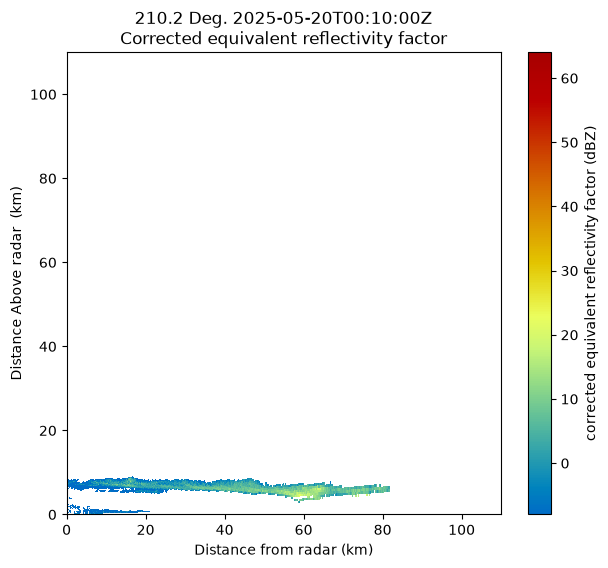

In [14]:
display = pyart.graph.RadarDisplay(cmac_radar)
fig = plt.figure(figsize=(7, 6))
display.plot_rhi('corrected_reflectivity', sweep=0, vmin=-8, vmax=64, cmap='HomeyerRainbow')

## 4. Quicklooks

Rather than building each plot by hand, `quicklooks_ppi` (or `quicklooks_rhi` for RHI volumes) produces the full standard set of CMAC diagnostic plots for a config in one call. Pass `return_figs=True` to get back a dict of `{plot_name: Figure}` instead of writing PNGs to disk.

##
## Keys for each gate id are as follows:
##    multi_trip
##    rain
##    snow
##    no_scatter
##    melting
##    clutter


['cmac_four_panel_plot',
 'corrected_differential_phase',
 'corrected_differential_reflectivity',
 'corrected_reflectivity',
 'corrected_specific_diff_phase',
 'corrected_velocity',
 'differential_phase',
 'filtered_corrected_differential_phase',
 'filtered_corrected_specific_diff_phase',
 'masked_corrected_reflectivity',
 'normalized_coherent_power',
 'path_integrated_differential_attenuation',
 'rain_rate_A',
 'reflectivity',
 'signal_to_noise_ratio',
 'specific_attenuation',
 'specific_differential_attenuation']

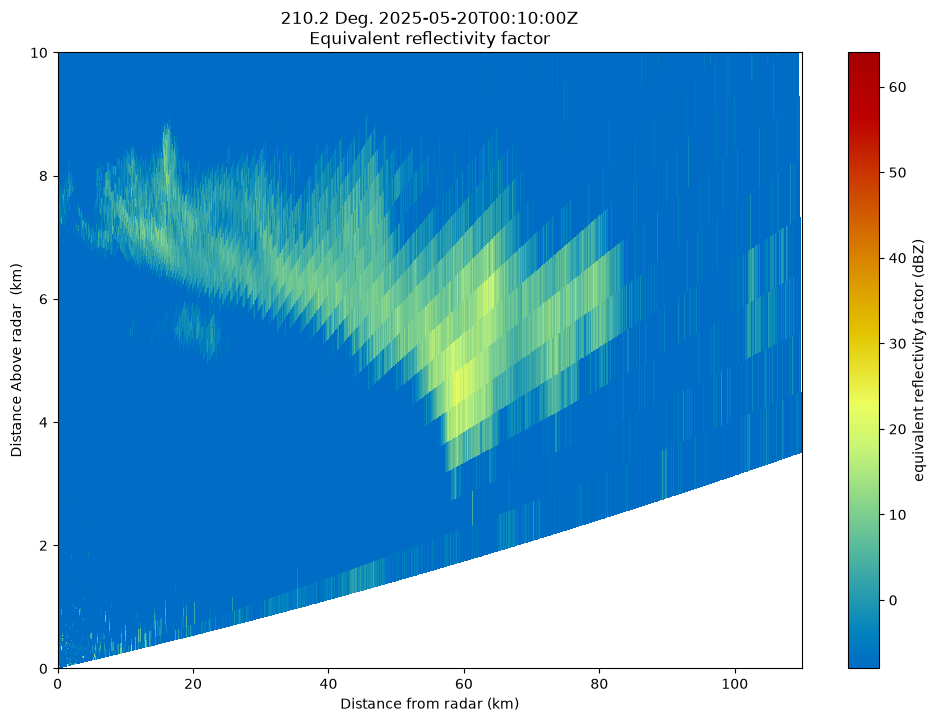

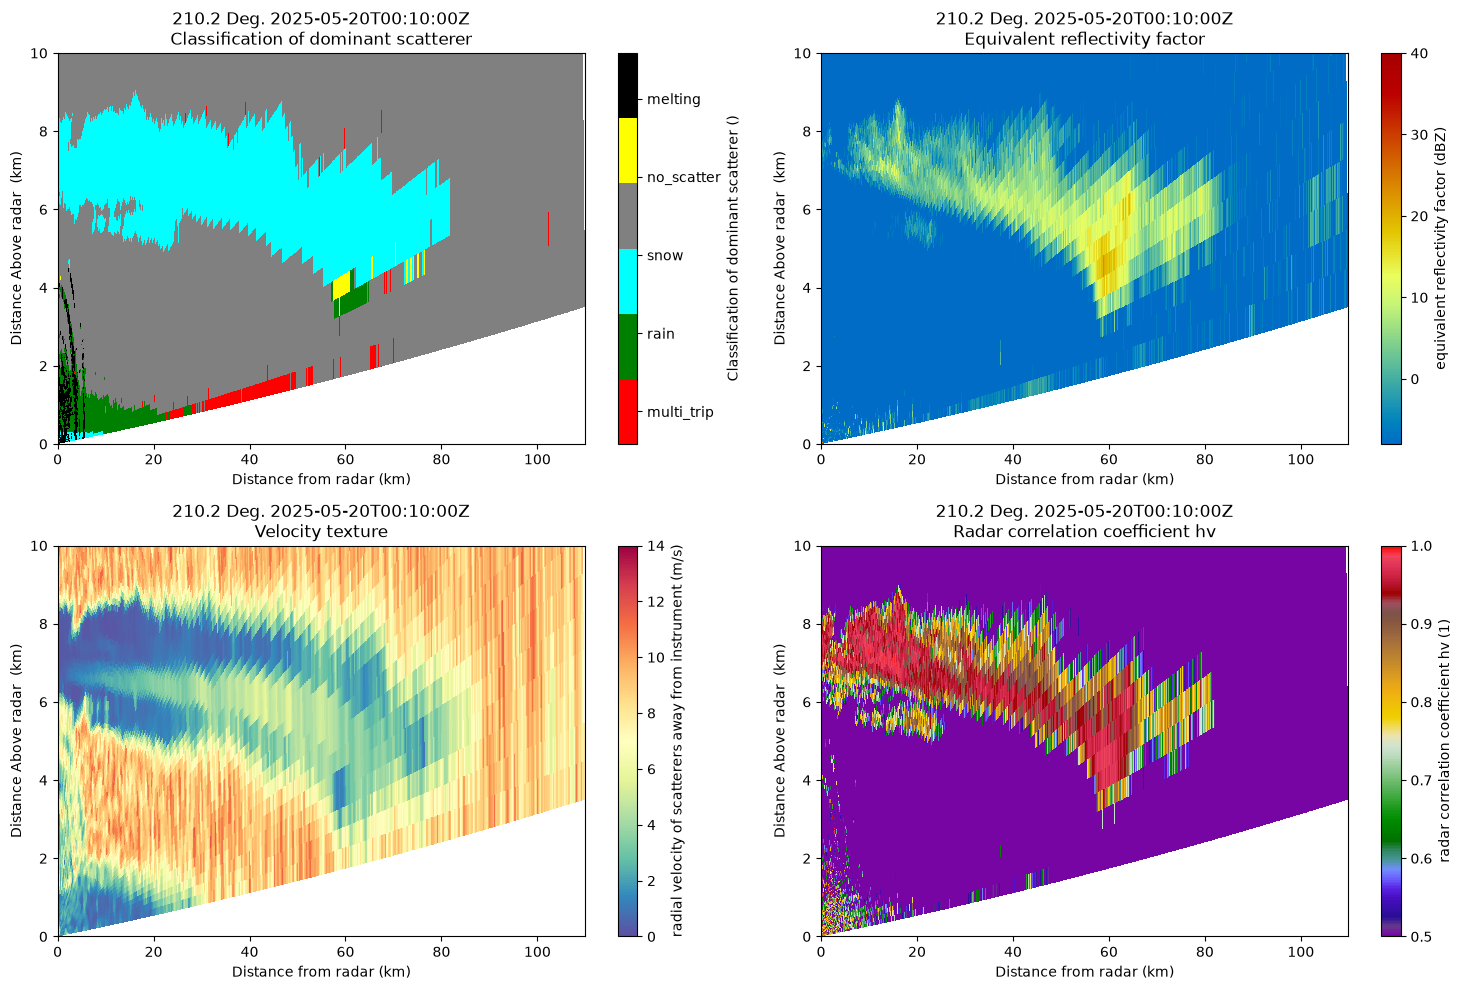

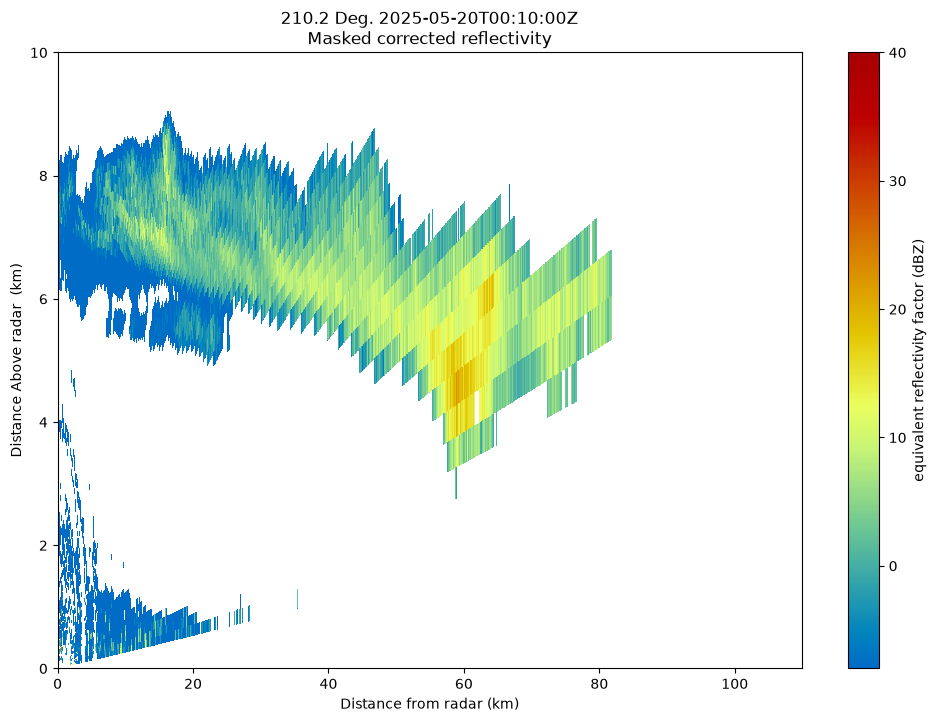

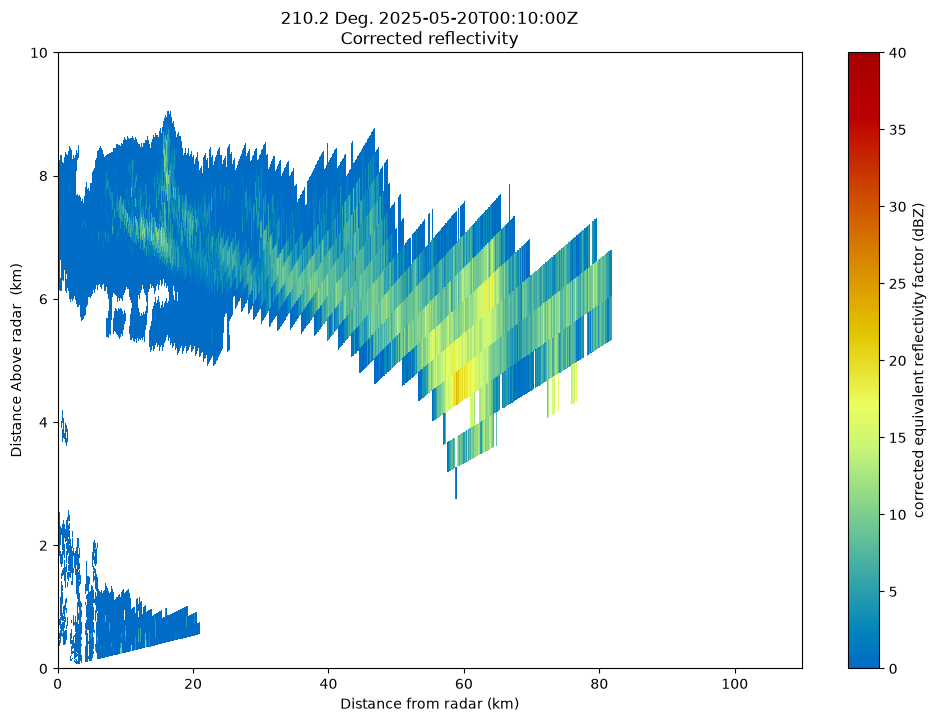

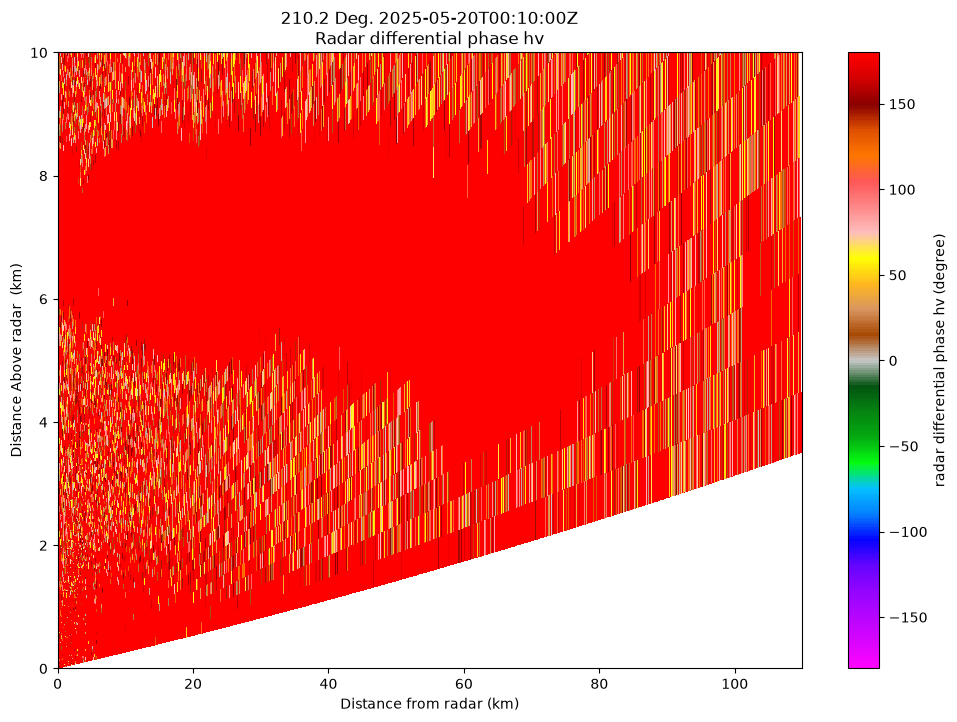

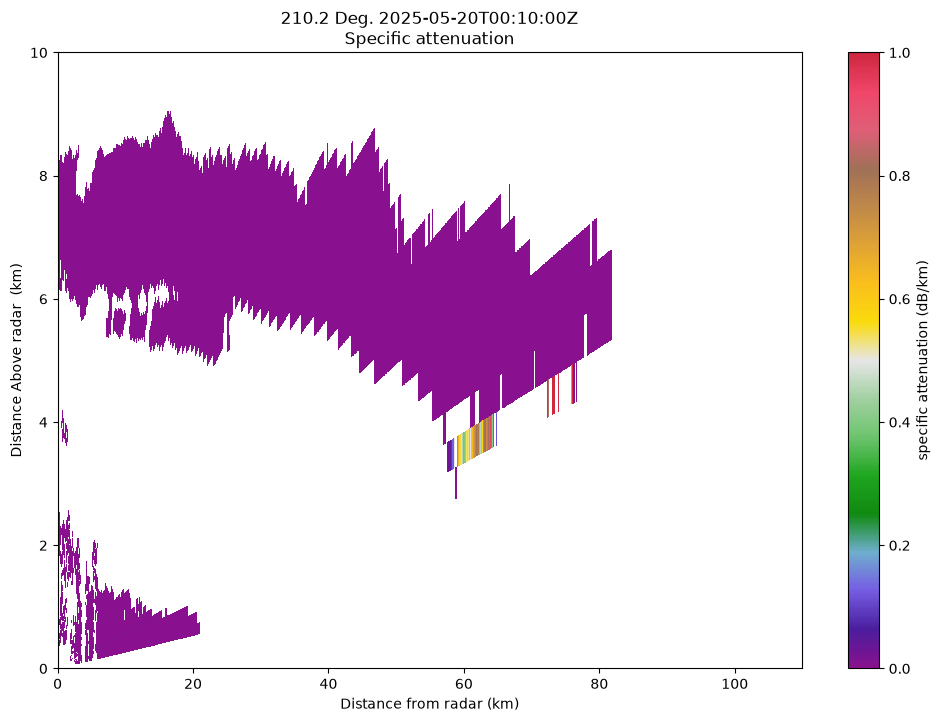

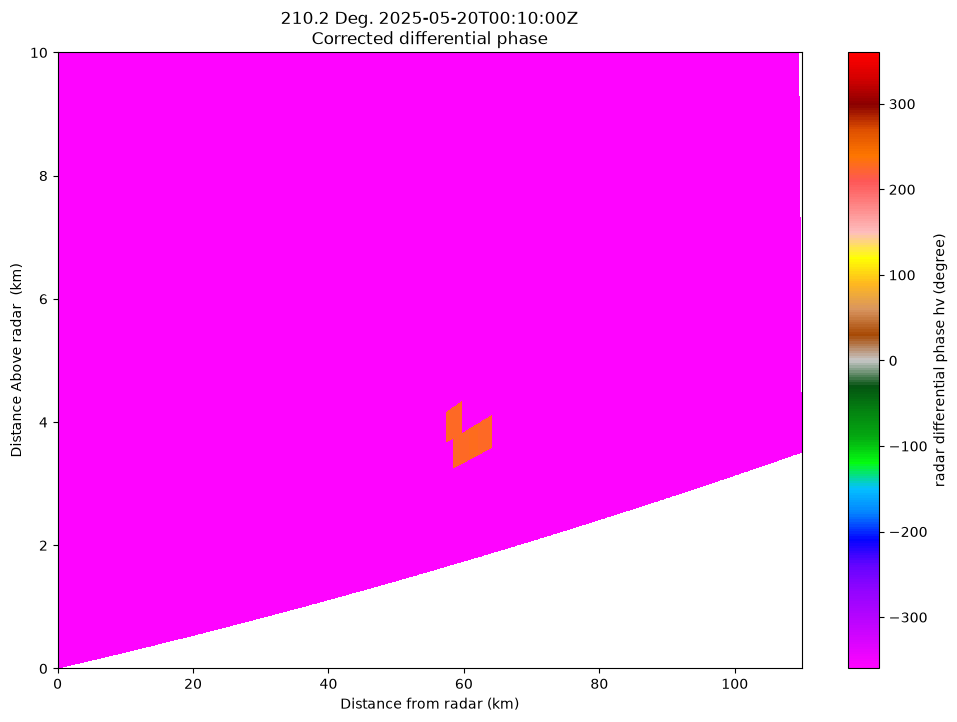

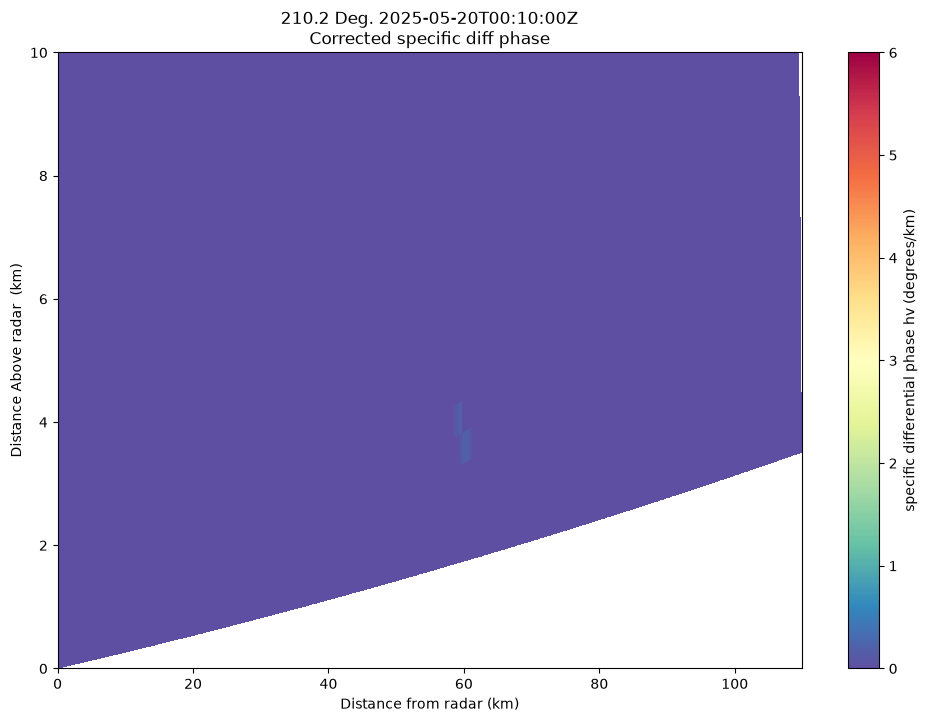

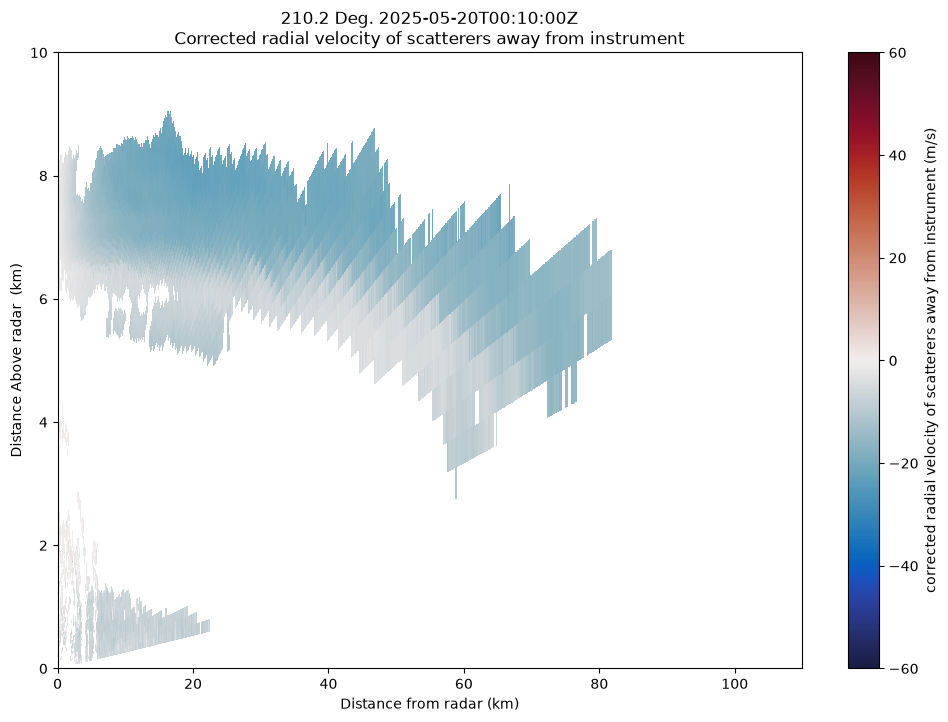

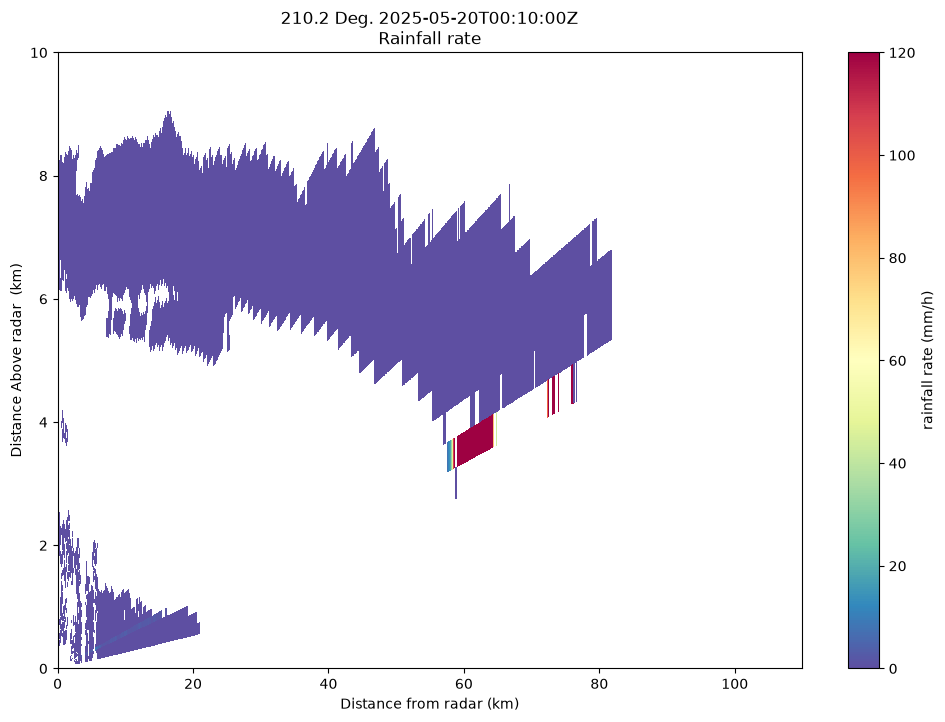

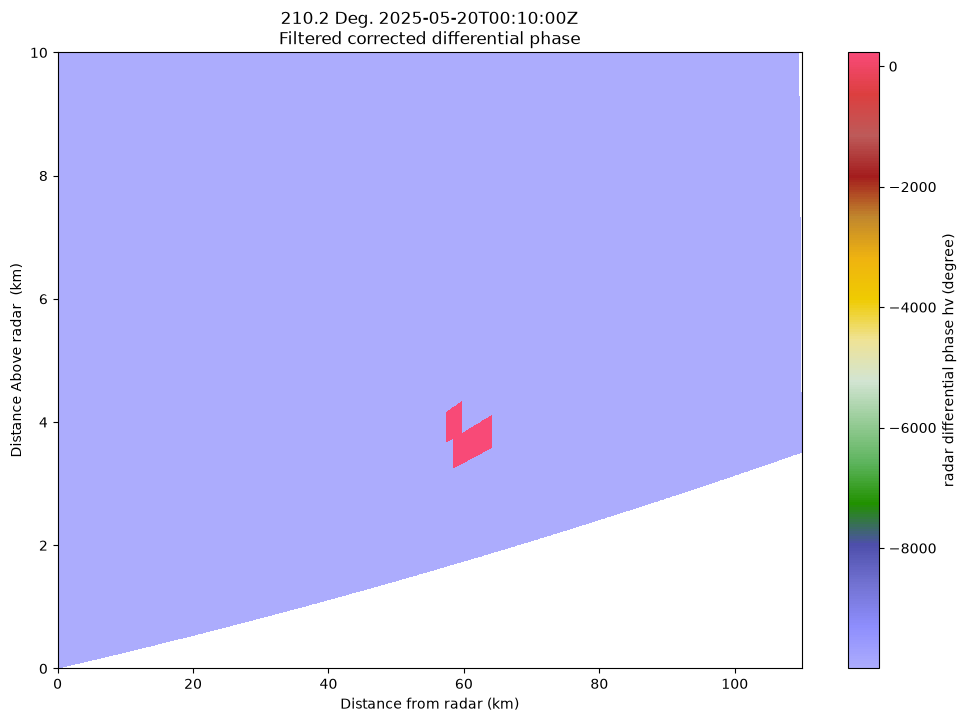

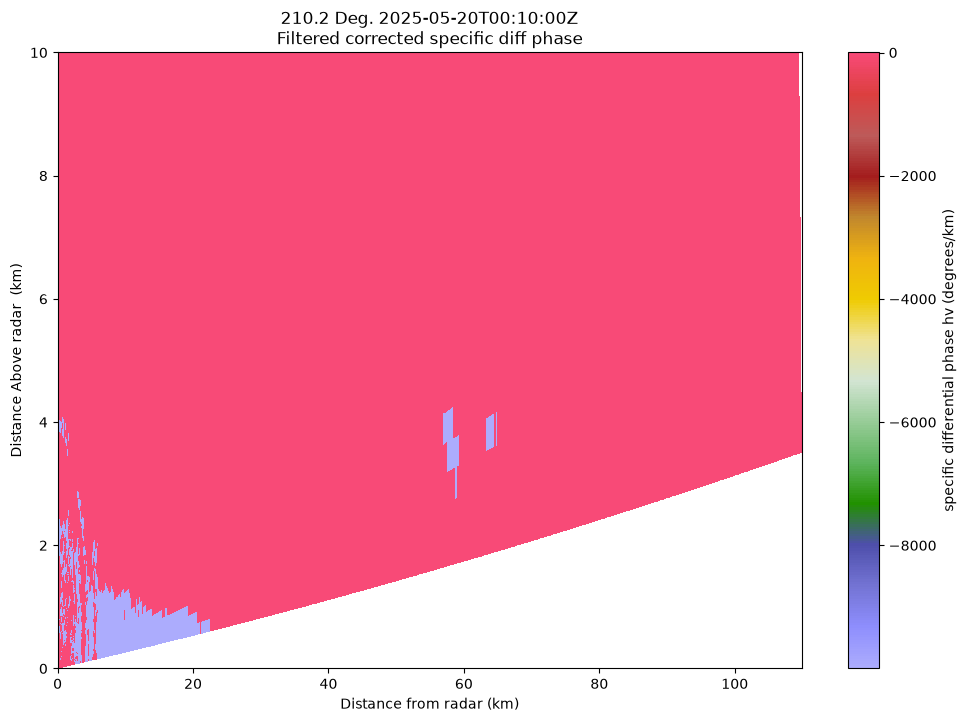

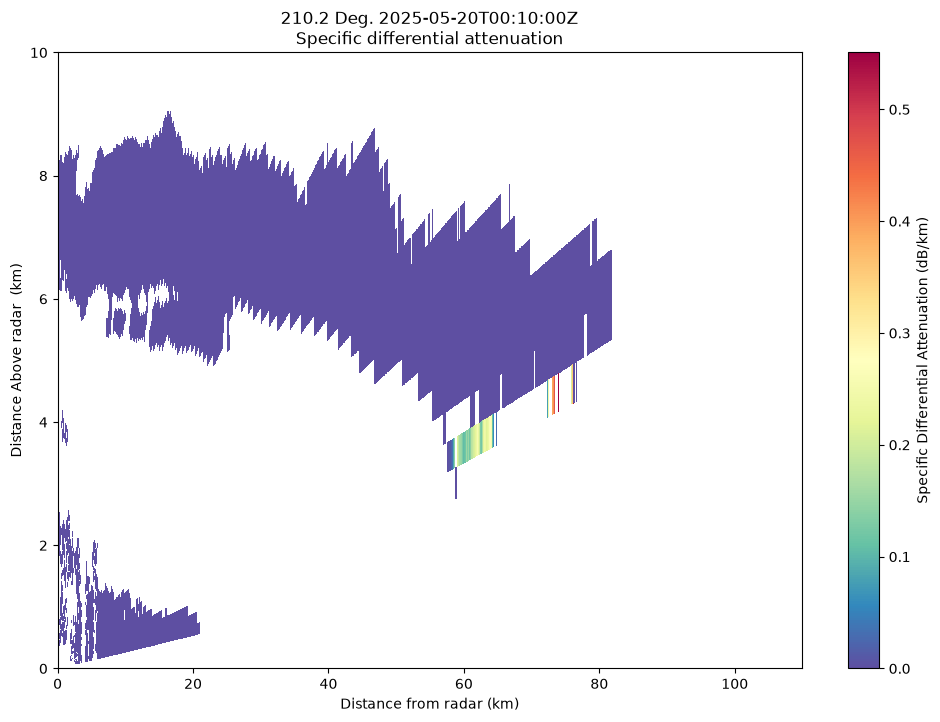

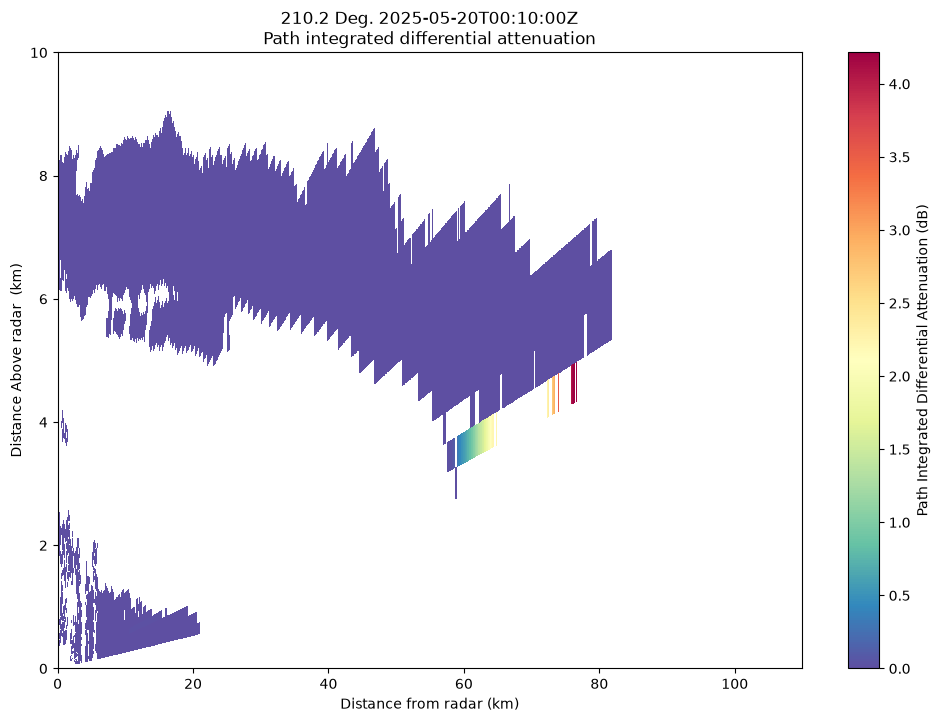

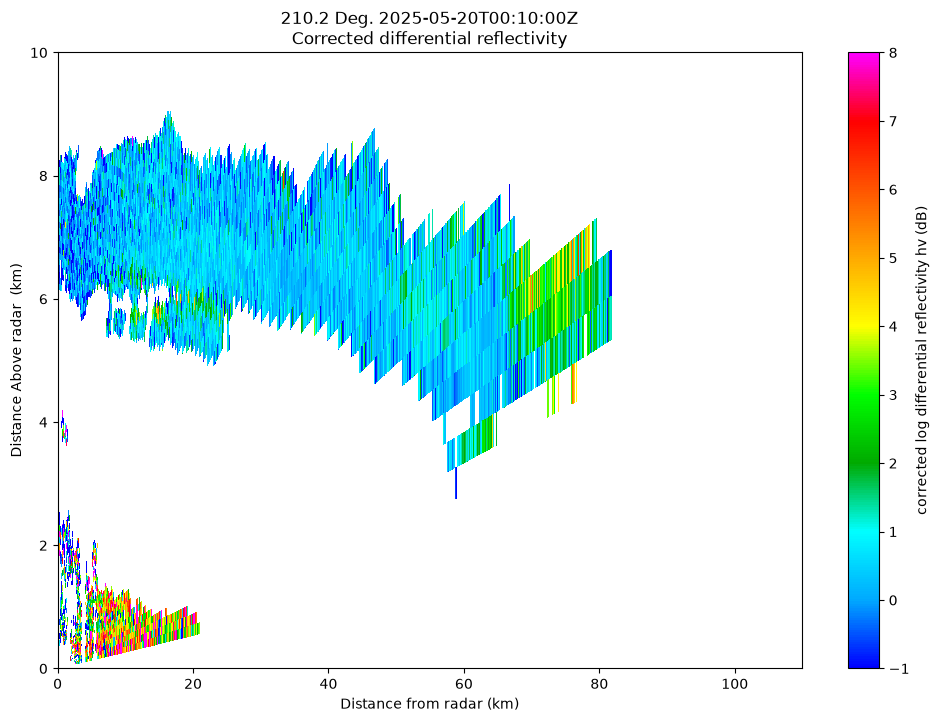

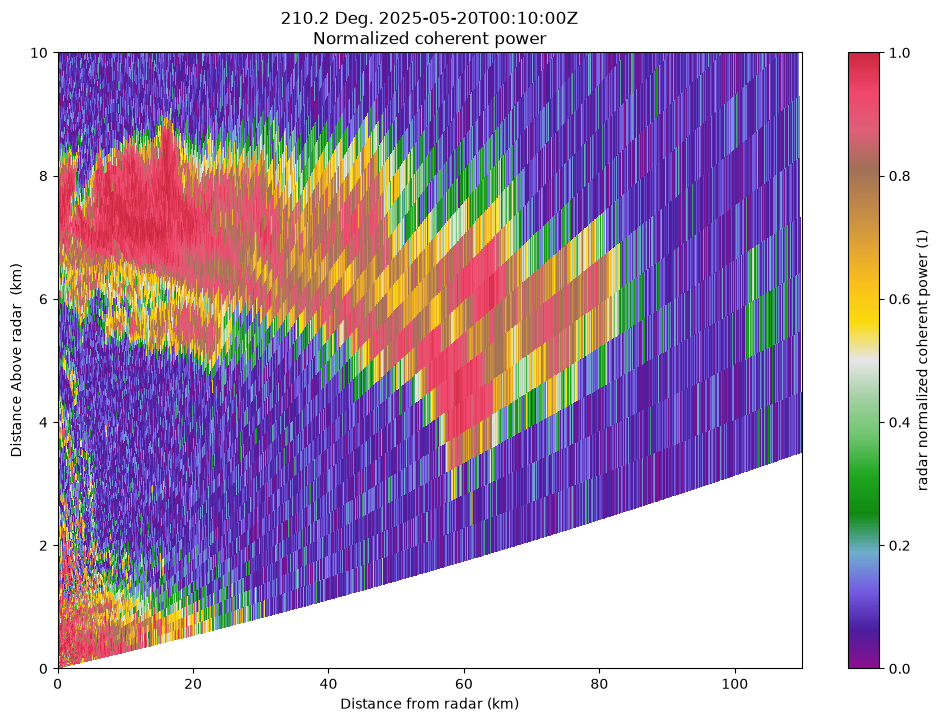

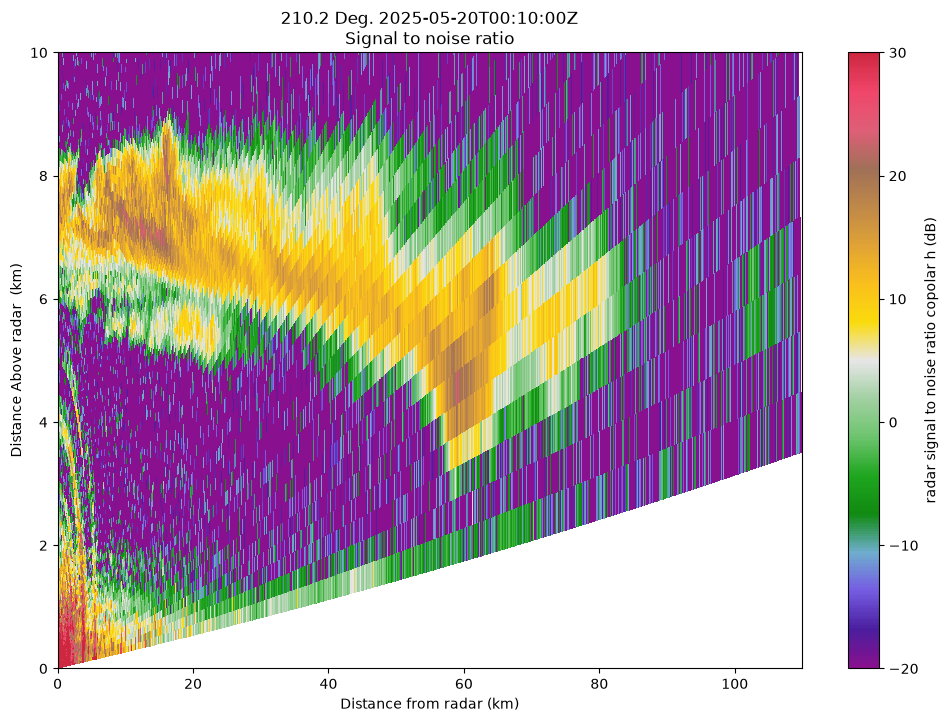

In [15]:
figures = quicklooks_rhi(cmac_radar, radar_config, sweep=0, return_figs=True)
sorted(figures.keys())

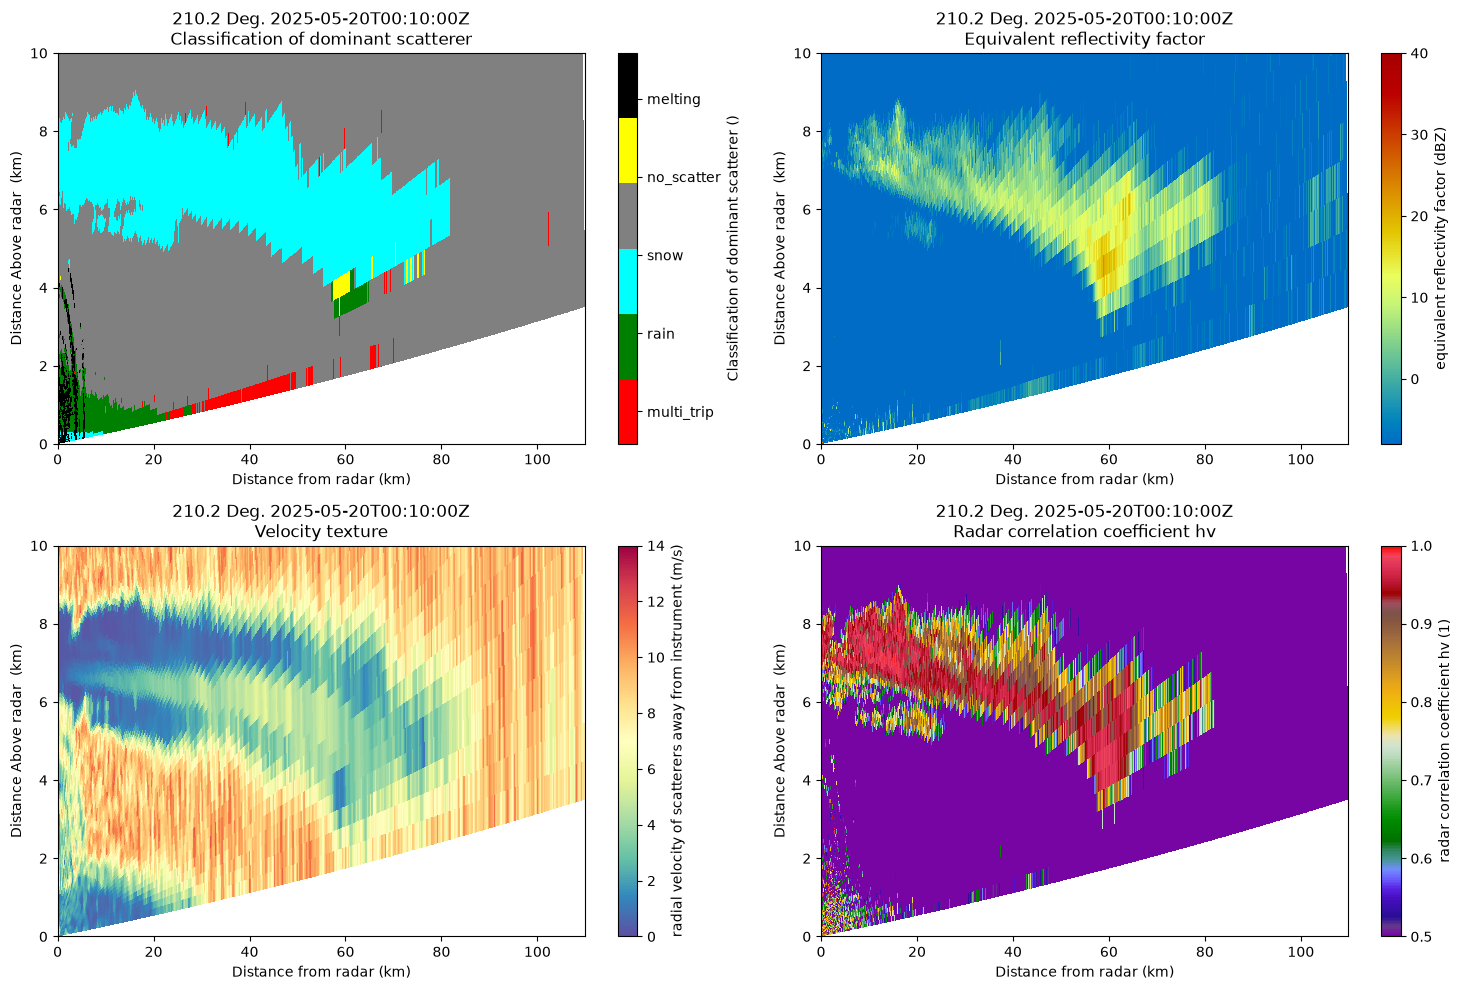

In [16]:
figures['cmac_four_panel_plot']

To write the quicklooks to disk instead, call `quicklooks_ppi(cmac_radar, radar_config, image_directory='/path/to/images')` without `return_figs`.

## 5. Area coverage

`area_coverage` reports the percentage of the lowest sweep covered by precipitation and by convection, using the corrected reflectivity field and the thresholds configured for `radar_config`.

In [17]:
precip_pct, convection_pct = area_coverage(cmac_radar, config=radar_config)
print(f'Precipitation coverage: {precip_pct:.1f}%')
print(f'Convection coverage: {convection_pct:.1f}%')

Precipitation coverage: 0.3%
Convection coverage: 0.0%


## 6. Save the CMAC output

The processed radar object is a regular Py-ART `Radar`, so it can be written out with any of Py-ART's writers, e.g. CfRadial:

In [18]:
out_path = os.path.join(data_dir, 'cmac_output.nc')
pyart.io.write_cfradial(out_path, cmac_radar)
print('Wrote', out_path)

Wrote ./cmac_example_data/cmac_output.nc


## Next steps

- All of the steps above are also wrapped up in the `cmac` command line script — see the `Using CMAC` section of the repository's `README.rst` for the equivalent one-line invocation.
- To process a radar that isn't already in `cmac.default_config`, write a YAML file with `metadata` / `field_names` / `cmac_values` / `plot_values` sections for it (see the docstring of `cmac.config`) and pass it as `config_file=` to `cmac()`, `quicklooks_ppi`/`quicklooks_rhi`, and `area_coverage`. `configs/bnfcsapr2.yaml` in this repository is a worked example.
- `cmac.cmac_processing` exposes the individual building blocks used inside `cmac()` (`do_my_fuzz`, `get_texture`, `snr_and_sounding`, `return_csu_kdp`, `retrieve_qvp`, `beam_block`, ...) if you need to run or tune a single step on its own.